<a href="https://colab.research.google.com/github/YuriiKlim/Amazinum_Camp/blob/Homeworks/Lesson5_Homework_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
import optuna
#optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
np.random.seed = 2021
from sklearn.datasets import load_iris

# 1. iris dataset

* load iris dataset
* split to train and test
* train KNN classifiers for different K
* choose the best K determined on test set

In [70]:
iris = load_iris()
df_iris = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])

df_iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [71]:
df_iris.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [72]:
class KNNOptunaClusterAnalysis:
    def __init__(self, dataset, train_percent, n_trials, neighbors_range, y_col, x_cols=None):
        """
        params:
            - dataset: pandas DataFrame with data.
            - train_percent: percentage of data to train.
            - n_trials: number of trials for Optuna.
            - neighbors_range: a tuple (min_neighbors, max_neighbors) to enumerate the number of neighbors.
            - y_col: the name of the column containing the labels (target).
            - x_cols: a list of column names for the features. If not specified, all columns except y_col are used.
        """
        self.dataset = dataset
        self.train_percent = train_percent
        self.n_trials = n_trials
        self.neighbors_range = neighbors_range
        self.y_col = y_col
        self.x_cols = x_cols
        self.best_overall_score = -np.inf
        self.best_overall_params = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

    def prepare_data(self):
        """
        Splits data into training and test samples.
        """
        if self.x_cols:
            X = self.dataset[self.x_cols].values
        else:
            X = self.dataset.drop(columns=[self.y_col]).values

        y = self.dataset[self.y_col].values

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, train_size=self.train_percent/100, random_state=42, stratify=y
        )

    def optimize_hyperparameters(self, n_neighbors):
        """
        Optimizes the hyperparameters for KNeighborsClassifier for a given number of neighbors.
        ------
        params:
            n_neighbors: the current value of the number of neighbors.
        return:
            tuple (best parameters, best score).
        """
        def objective(trial):
            weights = trial.suggest_categorical("weights", ["uniform", "distance"])
            algorithm = trial.suggest_categorical("algorithm", ["auto", "ball_tree", "kd_tree", "brute"])
            leaf_size = trial.suggest_int("leaf_size", 1, 50)
            p = trial.suggest_int("p", 1, 5)

            clf = KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights=weights,
                algorithm=algorithm,
                leaf_size=leaf_size,
                p=p,
                n_jobs=-1
            )
            clf.fit(self.X_train, self.y_train)
            y_pred = clf.predict(self.X_test)
            score = accuracy_score(self.y_test, y_pred)
            return score

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=self.n_trials)
        best_trial = study.best_trial
        return best_trial.params, best_trial.value

    def train_model(self, n_neighbors, hyperparams):
        """
        Train the KNeighborsClassifier model with a given number of neighbors and optimized hyperparameters.

        params
            n_neighbors: number of neighbors.
            hyperparams: dictionary with optimized hyperparameters.
        return:
            the trained model.
        """
        clf = KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=hyperparams["weights"],
            algorithm=hyperparams["algorithm"],
            leaf_size=hyperparams["leaf_size"],
            p=hyperparams["p"]
        )
        clf.fit(self.X_train, self.y_train)
        return clf

    def run_analysis(self):
        """
        Runs the full analysis cycle:
         1. Data preparation.
         2. For each value of n_neighbors, optimize hyperparameters and train the model.
         3. Update the best hyperparameters.

        :return:
        best_overall_params dictionary with the best hyperparameters (including n_neighbors).
        """
        self.prepare_data()

        for n_neighbors in range(self.neighbors_range[0], self.neighbors_range[1] + 1):
            hyperparams, score = self.optimize_hyperparameters(n_neighbors)
            clf = self.train_model(n_neighbors, hyperparams)

            # Update the best model if the current one has a higher score.
            if score > self.best_overall_score:
                self.best_overall_score = score
                self.best_overall_params = hyperparams.copy()
                self.best_overall_params["n_neighbors"] = n_neighbors

            print(f"Neighbors: {n_neighbors}, Accuracy: {score}")

        return self.best_overall_params

In [73]:
# Initialize the class with parameters

analysis = KNNOptunaClusterAnalysis(
    dataset=df_iris,
    train_percent=80,
    n_trials=100,
    neighbors_range=(1, 10),
    y_col="target"
)

# Run the analysis and get the best hyperparameters
best_params = analysis.run_analysis()
print("Best Hyperparameters:", best_params)

Neighbors: 1, Accuracy: 0.9666666666666667
Neighbors: 2, Accuracy: 0.9666666666666667
Neighbors: 3, Accuracy: 1.0
Neighbors: 4, Accuracy: 1.0
Neighbors: 5, Accuracy: 1.0
Neighbors: 6, Accuracy: 1.0
Neighbors: 7, Accuracy: 1.0
Neighbors: 8, Accuracy: 1.0
Neighbors: 9, Accuracy: 1.0
Neighbors: 10, Accuracy: 1.0
Best Hyperparameters: {'weights': 'distance', 'algorithm': 'kd_tree', 'leaf_size': 21, 'p': 5, 'n_neighbors': 3}


Best Hyperparameters
* weights - distance
* algorithm - kd_tree
* leaf_size - 21
* p - 5
* n_neighbors - 3

So the best K determined on test set is 3

# 2. synthetic dataset

* generrate synthetic dataset
* split to train and test
* train KNN regressors for different K
* choose the best K determined on test set
* visualize the decision boundary

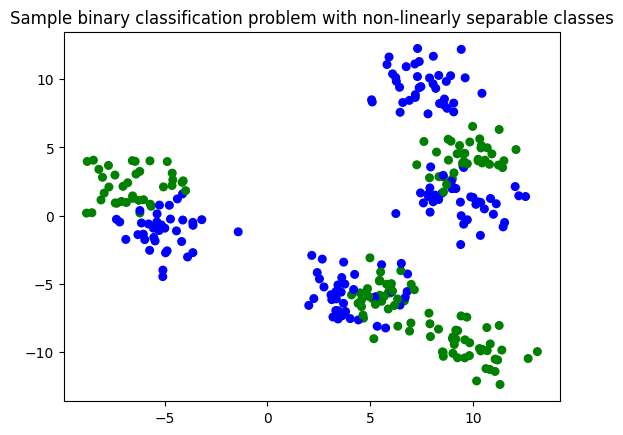

In [74]:
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_blobs

cmap_bold = ListedColormap(['blue','#FFFF00','black','green'])

np.random.seed= 2021
X_D2, y_D2 = make_blobs(n_samples = 300, n_features = 2, centers = 8,
                       cluster_std = 1.3, random_state = 4)
y_D2 = y_D2 % 2
plt.figure()
plt.title('Sample binary classification problem with non-linearly separable classes')
plt.scatter(X_D2[:,0], X_D2[:,1], c=y_D2,
           marker= 'o', s=30, cmap=cmap_bold)

In [75]:
df = pd.DataFrame(X_D2, columns=["feature1", "feature2"])
df["target"] = y_D2

df

,feature1,feature2,target
0,-5.971788,-1.759139,0
1,3.586356,-5.613891,0
2,6.662805,-6.252550,1
3,11.445015,3.524638,1
4,10.693343,-9.900922,1
...,...,...,...
295,10.380193,-9.919550,1
296,12.095520,4.849921,1
297,10.252850,4.131781,1
298,5.176469,-9.027085,1


In [76]:
analysis = KNNOptunaClusterAnalysis(
    dataset=df,
    train_percent=80,
    n_trials=100,
    neighbors_range=(1, 10),
    y_col="target"
)

best_params = analysis.run_analysis()
print("Best Hyperparameters:", best_params)

Neighbors: 1, Accuracy: 0.95
Neighbors: 2, Accuracy: 0.95
Neighbors: 3, Accuracy: 0.9666666666666667
Neighbors: 4, Accuracy: 0.9833333333333333
Neighbors: 5, Accuracy: 0.9666666666666667
Neighbors: 6, Accuracy: 0.9833333333333333
Neighbors: 7, Accuracy: 0.9666666666666667
Neighbors: 8, Accuracy: 0.9666666666666667
Neighbors: 9, Accuracy: 0.9666666666666667
Neighbors: 10, Accuracy: 0.9666666666666667
Best Hyperparameters: {'weights': 'distance', 'algorithm': 'brute', 'leaf_size': 4, 'p': 1, 'n_neighbors': 4}


Best Hyperparameters
* weights - distance
* algorithm - brute
* leaf_size - 4
* p - 1
* n_neighbors - 4

So the best K determined on synthetic set is 4

In [77]:
def plot_decision_boundary_from_best_params(dataset, best_params, y_col, x_cols=None):
    """
    Params:
      - dataset: pandas DataFrame with data.
      - best_params: a dictionary with hyperparameters.
      - y_col: the name of the column with the target values.
      - x_cols: a list of column names for the features. If not specified, all columns except y_col are taken.

    Function:
      1. Determines the features and the target (if more than 2 features are given, only the first 2 are used to build the decision boundary).
      2. Trains the KNeighborsClassifier model with the specified parameters on the entire dataset.
      3. Plots the decision boundary graph.
    """
    # Define the features (X) and the goal (y)
    if x_cols:
        X = dataset[x_cols].values
        feature_names = x_cols
    else:
        X = dataset.drop(columns=[y_col]).values
        feature_names = list(dataset.drop(columns=[y_col]).columns)

    y = dataset[y_col].values

    # 2D space is required to build the decision boundary.
    # If there are more than 2 features, only the first 2 are used.
    if X.shape[1] > 2:
        X_plot = X[:, :2]
        feature_names = feature_names[:2]
    else:
        X_plot = X

    # Create and train a model with the obtained parameters
    clf = KNeighborsClassifier(
        n_neighbors=best_params["n_neighbors"],
        weights=best_params["weights"],
        algorithm=best_params["algorithm"],
        leaf_size=best_params["leaf_size"],
        p=best_params["p"]
    )
    clf.fit(X_plot, y)

    # Create a grid to build a decision boundary
    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predict for each grid point
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Building a plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, edgecolor='k', s=30)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title("Decision Boundary")
    plt.show()

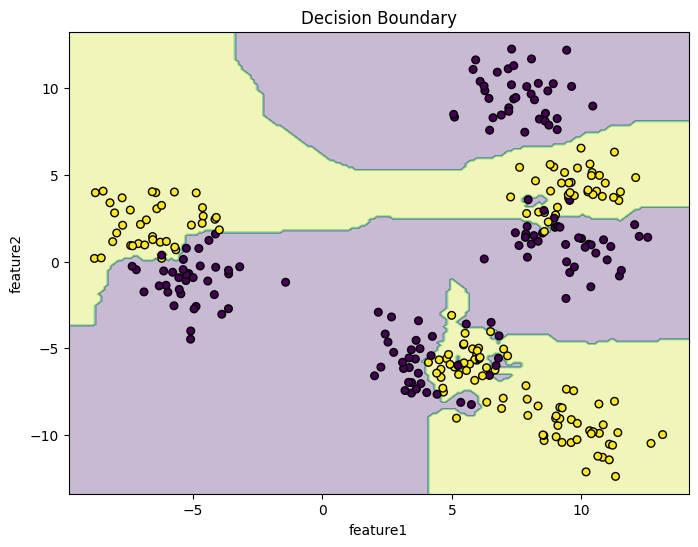

In [78]:
plot_decision_boundary = plot_decision_boundary_from_best_params(df, best_params, y_col="target")

plot_decision_boundary